In [1]:
## weekly registration test
import sys
print(sys.executable)
import os
os.environ["ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS"] = "16" # set the number of threads for ITK to use
from glob import glob
import wslPath

import ants
import matplotlib.pyplot as plt
import numpy as np
from skimage import io # Using scikit-image for potential multi-page support
from tqdm import tqdm
from pathlib import Path
import tifffile 

/mnt/d/Codex_folder/molecular_tracking/.venv/bin/python


In [ ]:
## list of function to write
## - [] crop images to much smaller FoV to speed up computing
##      - only do like 256*256*41?
## - [] get date from file name and group them in weeks (Monday to Sunday)
## - [] find the medoid image of that week (it's likely the middle date or the first day since all images are aligned to it)

XY_SPACING_UM = 710.0 / 1024.0
Z_SPACING_UM = 5.0
SPACING_ZYX = (Z_SPACING_UM, XY_SPACING_UM, XY_SPACING_UM)


def ants_from_zyx(array, *, is_label=False):
    """Create a 3D ANTs image from a Z, Y, X NumPy array."""
    array = np.asarray(array)
    if array.ndim != 3:
        raise ValueError(f"Expected a 3D ZYX array, received shape {array.shape}")

    dtype = np.uint32 if is_label else np.float32
    return ants.from_numpy(
        array.astype(dtype, copy=False),
        spacing=SPACING_ZYX,
        origin=(0.0, 0.0, 0.0),
        direction=np.eye(3),
    )


def crop_images(image_path,crop_size=512):
    image_path = wslPath.to_posix(image_path)
    image_path = Path(image_path)
    image_array = io.imread(image_path)
    print(f"now processing {image_path.name}")    
    z,y,x = image_array.shape
    crop_size = crop_size
    crop_image_array = image_array[:,y//2-crop_size//2:y//2+crop_size//2,x//2-crop_size//2:x//2+crop_size//2]
    parent_dir = image_path.parent
    output_dir = parent_dir / f"crop_{crop_size}"
    output_fname = output_dir / f"{image_path.name.split('.tif')[0]}_crop_{crop_size}.tif"
    output_dir.mkdir(parents=True, exist_ok=True)
    io.imsave(output_fname, crop_image_array, check_contrast=False)
    # print(f"Output file saved: {output_fname.name}")

from pathlib import Path
from datetime import datetime
from collections import defaultdict

def group_files_by_week(file_list):
    week_groups = defaultdict(list)

    for file_path in file_list:
        filename = Path(file_path).name
        date_str = filename.split("_")[0]   # "20260511"

        date = datetime.strptime(date_str, "%Y%m%d").date()

        # Monday of that week
        week_start = date.fromordinal(date.toordinal() - date.weekday())

        week_groups[week_start].append(file_path)

    # Sort weeks chronologically and rename as week1, week2, ...
    week_dict = {}
    for i, week_start in enumerate(sorted(week_groups), start=1):
        week_dict[f"week{i}"] = sorted(week_groups[week_start])

    return week_dict

In [3]:
## loop through images and make cropped images

folder_path = r"D:\_data\_newAAV_2026\weekly_registration_test"
folder_path = wslPath.to_posix(folder_path)
file_list = sorted(glob(f"{folder_path}/*.tif"))
file_list = [f for f in file_list if 'SyN' not in f] # in case there are already registered files
file_list = [f for f in file_list if 'masks' not in f] # in case there are already registered ROI mask files
file_list = [f for f in file_list if 'dark' not in f] # in case there is a dark value image


## do cropping here
do_crop_image = True
if do_crop_image:
    crop_size = 64
    _ = [crop_images(wslPath.to_windows(f),crop_size=crop_size) for f in file_list]

    ## remove all file with SyN, masks average
    # cropped_folder_path = Path(r"D:\_data\_newAAV_2026\weekly_registration_test\crop_256")
    cropped_folder_path = Path(rf"D:\_data\_newAAV_2026\weekly_registration_test\crop_{crop_size}")

    cropped_folder_path = wslPath.to_posix(cropped_folder_path)
    file_list = glob(f"{cropped_folder_path}/*.tif")
    file_list
    ## remove all file with SyN, masks average
    for file in file_list:
        if "SyN" in file or "masks" in file or "average" in file:
            os.remove(file)
    file_list = glob(f"{cropped_folder_path}/*.tif")
    file_list
    
    cropped_file_list = sorted(glob(f"{folder_path}/crop_{crop_size}/*.tif"))

    cropped_file_list = [f for f in cropped_file_list if 'average' not in f]
    cropped_file_list = [f for f in cropped_file_list if 'SyN' not in f]

    week_dict = []
    week_dict = group_files_by_week(cropped_file_list)
    week_dict
else:
    week_dict = group_files_by_week(file_list) # full dataset

now processing 20260511_G.tif
Output file saved: 20260511_G_crop_64.tif
now processing 20260511_R.tif
Output file saved: 20260511_R_crop_64.tif
now processing 20260512_G.tif
Output file saved: 20260512_G_crop_64.tif
now processing 20260512_R.tif
Output file saved: 20260512_R_crop_64.tif
now processing 20260513_G.tif
Output file saved: 20260513_G_crop_64.tif
now processing 20260513_R.tif
Output file saved: 20260513_R_crop_64.tif
now processing 20260514_G.tif
Output file saved: 20260514_G_crop_64.tif
now processing 20260514_R.tif
Output file saved: 20260514_R_crop_64.tif
now processing 20260515_G.tif
Output file saved: 20260515_G_crop_64.tif
now processing 20260515_R.tif
Output file saved: 20260515_R_crop_64.tif
now processing 20260518_G.tif
Output file saved: 20260518_G_crop_64.tif
now processing 20260518_R.tif
Output file saved: 20260518_R_crop_64.tif
now processing 20260519_G.tif
Output file saved: 20260519_G_crop_64.tif
now processing 20260519_R.tif
Output file saved: 20260519_R_crop

In [4]:

# cropped_file_list = sorted(glob(f"{folder_path}/crop_{crop_size}/*.tif"))

# cropped_file_list = [f for f in cropped_file_list if 'average' not in f]
# cropped_file_list = [f for f in cropped_file_list if 'SyN' not in f]

# week_dict = []
# week_dict = group_files_by_week(cropped_file_list)
# week_dict

# # ## now try week_dic for real images

# # folder_path = r"D:\_data\_newAAV_2026\weekly_registration_test"
# # folder_path = wslPath.to_posix(folder_path)
# # file_list = sorted(glob(f"{folder_path}/*.tif"))
# # file_list = [f for f in file_list if 'SyN' not in f] # in case there are already registered files
# # file_list = [f for f in file_list if 'masks' not in f] # in case there are already registered ROI mask files
# # file_list = [f for f in file_list if 'dark' not in f] # in case there is a dark value image
# # week_dict = group_files_by_week(file_list)
# # week_dict

[GUI INFO] : WRITING LOG OUTPUT TO /home/hunglinux/.cellpose/run.log

cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.3 
torch version:  	2.11.0+cu128
2026-07-13 09:45:35,442 [io INFO] WRITING LOG OUTPUT TO /home/hunglinux/.cellpose/run.log
2026-07-13 09:45:35,443 [io INFO] 
cellpose version: 	4.2.1.1 
platform:       	linux 
python version: 	3.12.3 
torch version:  	2.11.0+cu128
2026-07-13 09:45:35,445 [core INFO] ** TORCH CUDA version installed and working. **
2026-07-13 09:45:35,445 [core INFO] >>>> using GPU (CUDA)


2026-07-13 09:45:36,822 [models INFO] >>>> loading model /home/hunglinux/.cellpose/models/cpsam_v2


Weeks:   0%|          | 0/9 [00:00<?, ?it/s]

Processing week1 (5 red-channel images)


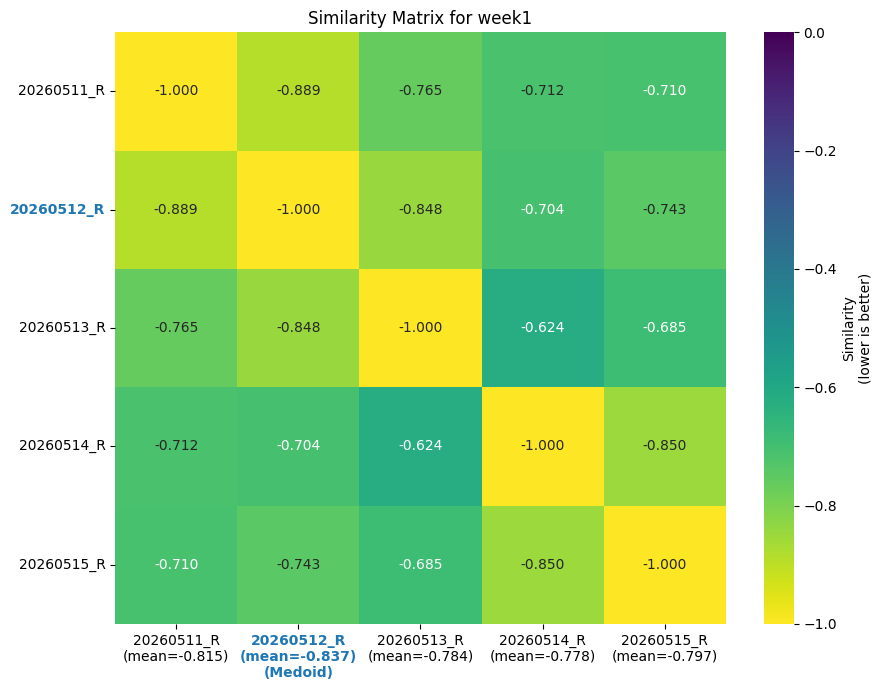

Weeks:   0%|          | 0/9 [00:07<?, ?it/s]

Medoid image for week1: 20260512_R_crop_64.tif
NumPy shape: (41, 64, 64)
ANTs shape: (41, 64, 64)
ANTs spacing (ZYX, um): (5.0, 0.693359375, 0.693359375)
Approximate physical extent (um): (205.0, 44.375, 44.375)



Weeks:   0%|          | 0/9 [00:08<?, ?it/s]                          

Registered image saved: 20260511_R_crop_64_SyN.tif
Registered G channel image saved: 20260511_G_crop_64_SyN.tif
Medoid image copied to: 20260512_R_crop_64_SyN.tif
Medoid G channel image copied to: 20260512_G_crop_64_SyN.tif



Weeks:   0%|          | 0/9 [00:10<?, ?it/s]                          

...


Weeks:   0%|          | 0/9 [00:12<?, ?it/s]                          

Registered image saved: 20260515_R_crop_64_SyN.tif
Registered G channel image saved: 20260515_G_crop_64_SyN.tif
Average image saved: week1_average.tif
2026-07-13 09:45:50,217 [io INFO] reading tiff with 41 planes


100%|██████████| 41/41 [00:00<00:00, 1877.51it/s]

2026-07-13 09:45:50,246 [core INFO] running YX: 41 planes of size (64, 64)
2026-07-13 09:45:50,246 [utils INFO] 
2026-07-13 09:45:50,247 [utils INFO] 0%|          | 0/6 [00:00<?, ?it/s]
2026-07-13 09:45:50,247 [utils INFO] 


2026-07-13 09:45:51,383 [utils INFO] 100%|##########| 6/6 [00:01<00:00,  5.28it/s]
2026-07-13 09:45:51,384 [core INFO] running ZY: 64 planes of size (41, 64)
2026-07-13 09:45:51,385 [utils INFO] 
2026-07-13 09:45:51,385 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:45:51,386 [utils INFO] 
2026-07-13 09:45:52,779 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.75it/s]
2026-07-13 09:45:52,780 [core INFO] running ZX: 64 planes of size (41, 64)
2026-07-13 09:45:52,781 [utils INFO] 
2026-07-13 09:45:52,781 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:45:52,781 [utils INFO] 
2026-07-13 09:45:54,175 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.74it/s]
2026-07-13 09:45:54,177 [models INFO] network run in 3.93s
2026-07-13 09:45:54,206 [models INFO] masks created in 0.03s


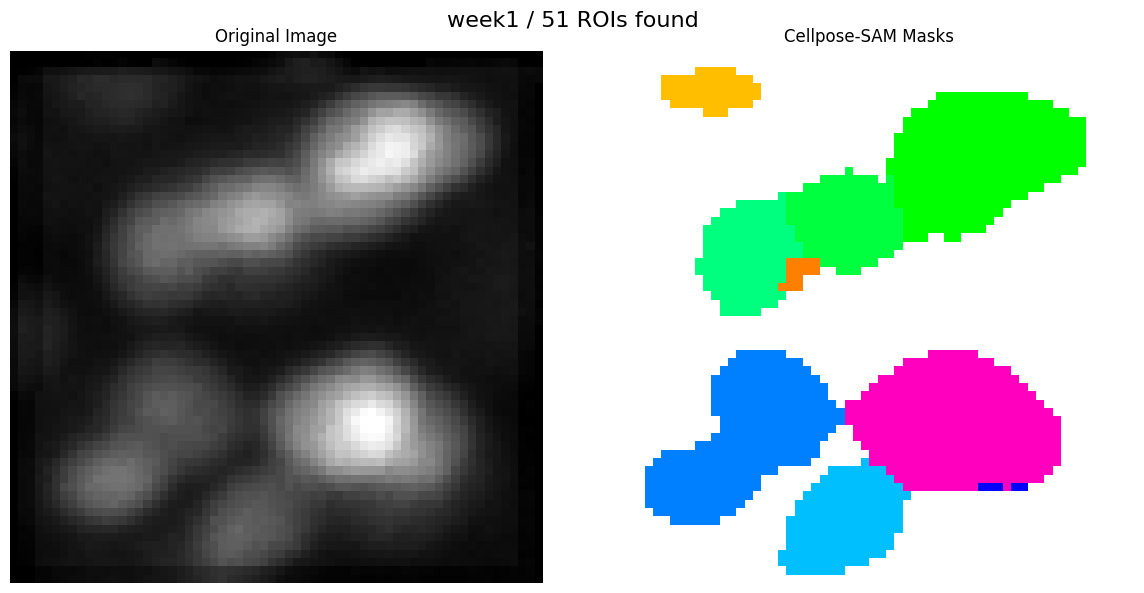

Weeks:  11%|█         | 1/9 [00:16<02:12, 16.60s/it]

Mask image saved: week1_average_cp_masks.tif
Processing week2 (4 red-channel images)


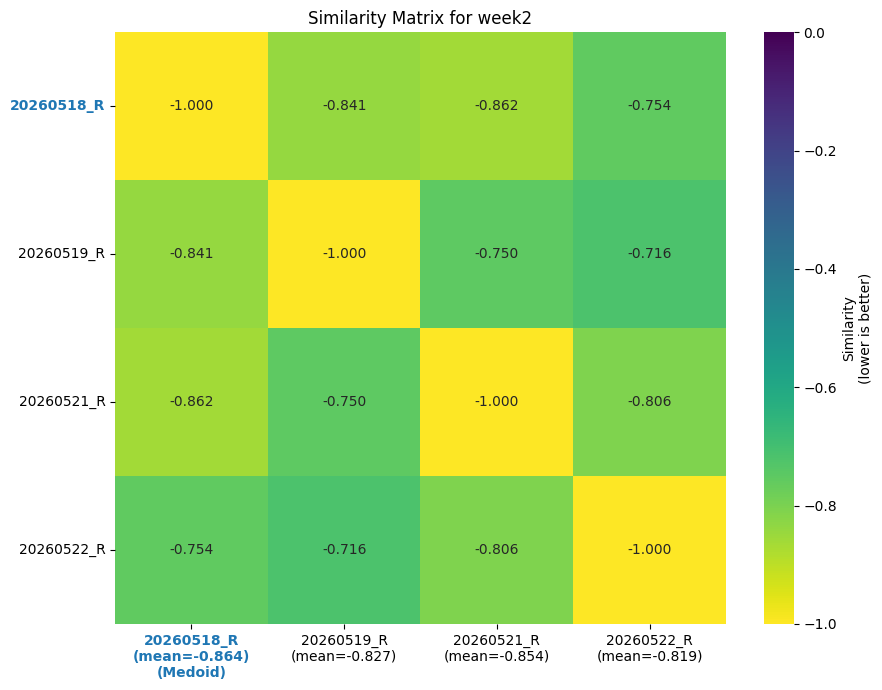

Weeks:  11%|█         | 1/9 [00:24<02:12, 16.60s/it]

Medoid image for week2: 20260518_R_crop_64.tif
NumPy shape: (41, 64, 64)
ANTs shape: (41, 64, 64)
ANTs spacing (ZYX, um): (5.0, 0.693359375, 0.693359375)
Approximate physical extent (um): (205.0, 44.375, 44.375)



Weeks:  11%|█         | 1/9 [00:24<02:12, 16.60s/it]          

Medoid image copied to: 20260518_R_crop_64_SyN.tif
Medoid G channel image copied to: 20260518_G_crop_64_SyN.tif



Weeks:  11%|█         | 1/9 [00:26<02:12, 16.60s/it]          

...


Weeks:  11%|█         | 1/9 [00:28<02:12, 16.60s/it]                  

Registered image saved: 20260522_R_crop_64_SyN.tif
Registered G channel image saved: 20260522_G_crop_64_SyN.tif
Average image saved: week2_average.tif
2026-07-13 09:46:06,596 [io INFO] reading tiff with 41 planes


100%|██████████| 41/41 [00:00<00:00, 1904.29it/s]

2026-07-13 09:46:06,623 [core INFO] running YX: 41 planes of size (64, 64)
2026-07-13 09:46:06,623 [utils INFO] 
2026-07-13 09:46:06,624 [utils INFO] 0%|          | 0/6 [00:00<?, ?it/s]
2026-07-13 09:46:06,624 [utils INFO] 


2026-07-13 09:46:07,735 [utils INFO] 100%|##########| 6/6 [00:01<00:00,  5.40it/s]
2026-07-13 09:46:07,737 [core INFO] running ZY: 64 planes of size (41, 64)
2026-07-13 09:46:07,737 [utils INFO] 
2026-07-13 09:46:07,738 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:46:07,738 [utils INFO] 
2026-07-13 09:46:09,119 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.80it/s]
2026-07-13 09:46:09,120 [core INFO] running ZX: 64 planes of size (41, 64)
2026-07-13 09:46:09,121 [utils INFO] 
2026-07-13 09:46:09,121 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:46:09,121 [utils INFO] 
2026-07-13 09:46:10,492 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.84it/s]
2026-07-13 09:46:10,495 [models INFO] network run in 3.87s
2026-07-13 09:46:10,522 [models INFO] masks created in 0.03s


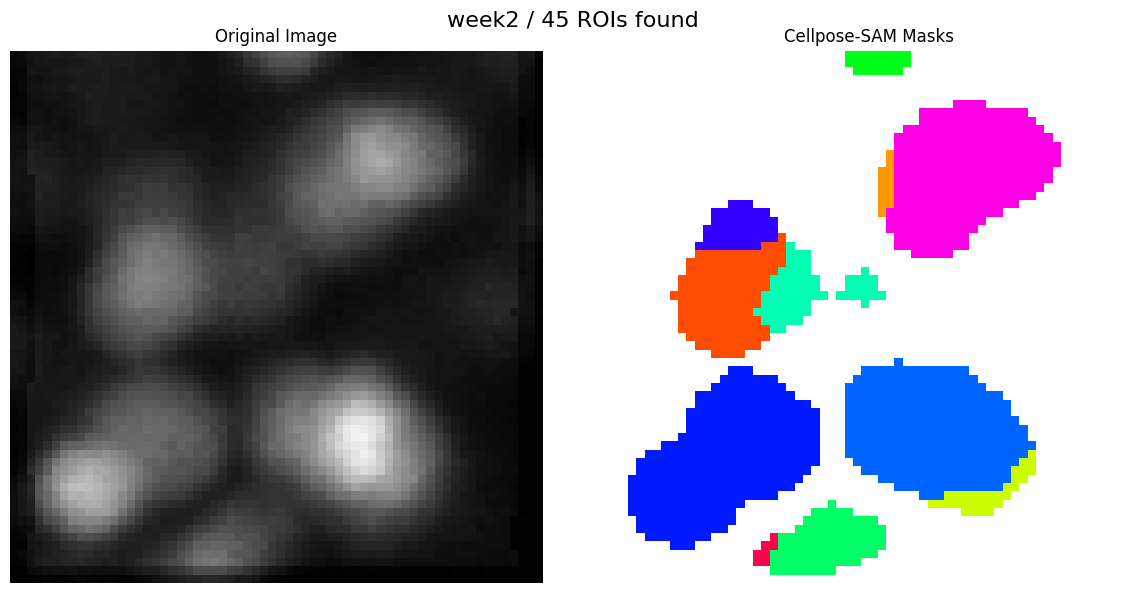

Weeks:  22%|██▏       | 2/9 [00:32<01:55, 16.43s/it]

Mask image saved: week2_average_cp_masks.tif
Processing week3 (4 red-channel images)


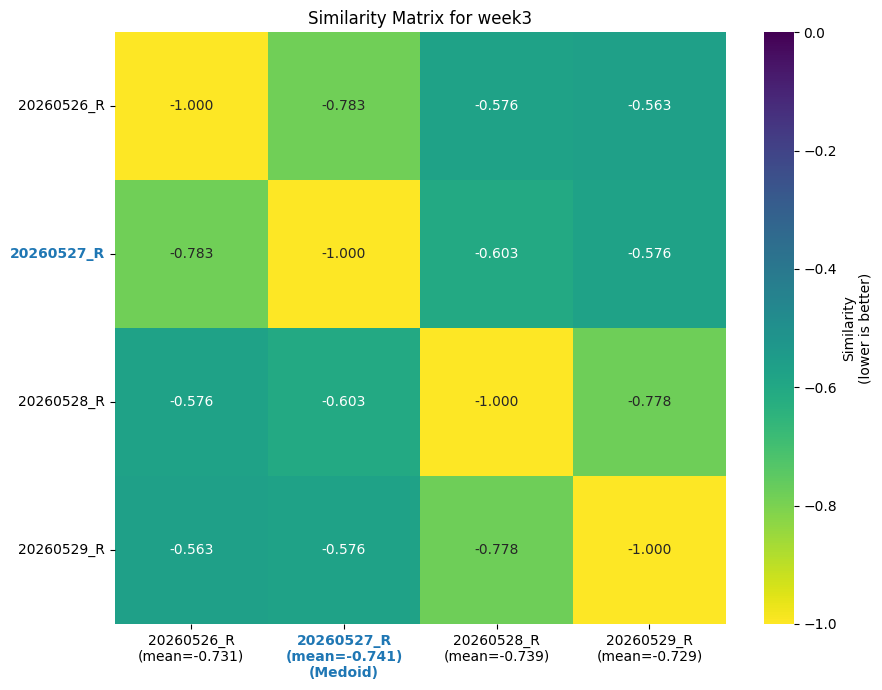

Weeks:  22%|██▏       | 2/9 [00:37<01:55, 16.43s/it]

Medoid image for week3: 20260527_R_crop_64.tif
NumPy shape: (41, 64, 64)
ANTs shape: (41, 64, 64)
ANTs spacing (ZYX, um): (5.0, 0.693359375, 0.693359375)
Approximate physical extent (um): (205.0, 44.375, 44.375)



Weeks:  22%|██▏       | 2/9 [00:38<01:55, 16.43s/it]                  

Registered image saved: 20260526_R_crop_64_SyN.tif
Registered G channel image saved: 20260526_G_crop_64_SyN.tif
Medoid image copied to: 20260527_R_crop_64_SyN.tif
Medoid G channel image copied to: 20260527_G_crop_64_SyN.tif



Weeks:  22%|██▏       | 2/9 [00:40<01:55, 16.43s/it]                  

...


Weeks:  22%|██▏       | 2/9 [00:41<01:55, 16.43s/it]                  

Registered image saved: 20260529_R_crop_64_SyN.tif
Registered G channel image saved: 20260529_G_crop_64_SyN.tif
Average image saved: week3_average.tif
2026-07-13 09:46:19,584 [io INFO] reading tiff with 41 planes


100%|██████████| 41/41 [00:00<00:00, 1958.82it/s]

2026-07-13 09:46:19,611 [core INFO] running YX: 41 planes of size (64, 64)
2026-07-13 09:46:19,611 [utils INFO] 
2026-07-13 09:46:19,612 [utils INFO] 0%|          | 0/6 [00:00<?, ?it/s]
2026-07-13 09:46:19,612 [utils INFO] 


2026-07-13 09:46:20,713 [utils INFO] 100%|##########| 6/6 [00:01<00:00,  5.45it/s]
2026-07-13 09:46:20,715 [core INFO] running ZY: 64 planes of size (41, 64)
2026-07-13 09:46:20,716 [utils INFO] 
2026-07-13 09:46:20,716 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:46:20,716 [utils INFO] 
2026-07-13 09:46:22,127 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.67it/s]
2026-07-13 09:46:22,128 [core INFO] running ZX: 64 planes of size (41, 64)
2026-07-13 09:46:22,129 [utils INFO] 
2026-07-13 09:46:22,129 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:46:22,130 [utils INFO] 
2026-07-13 09:46:23,526 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.73it/s]
2026-07-13 09:46:23,529 [models INFO] network run in 3.92s
2026-07-13 09:46:23,558 [models INFO] masks created in 0.03s


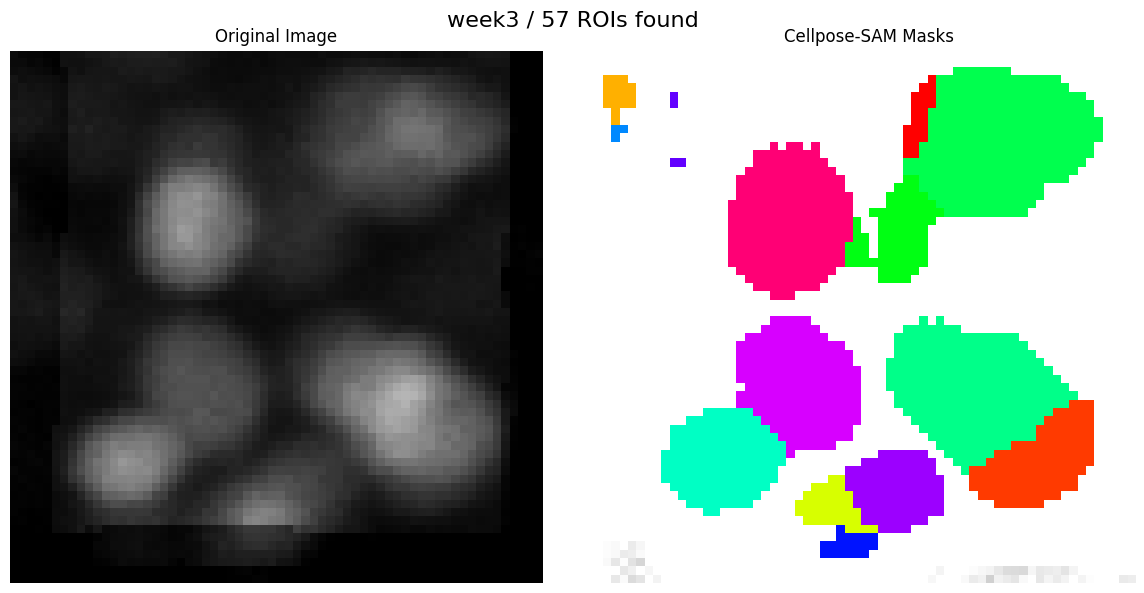

Weeks:  33%|███▎      | 3/9 [00:45<01:29, 14.88s/it]

Mask image saved: week3_average_cp_masks.tif
Processing week4 (5 red-channel images)


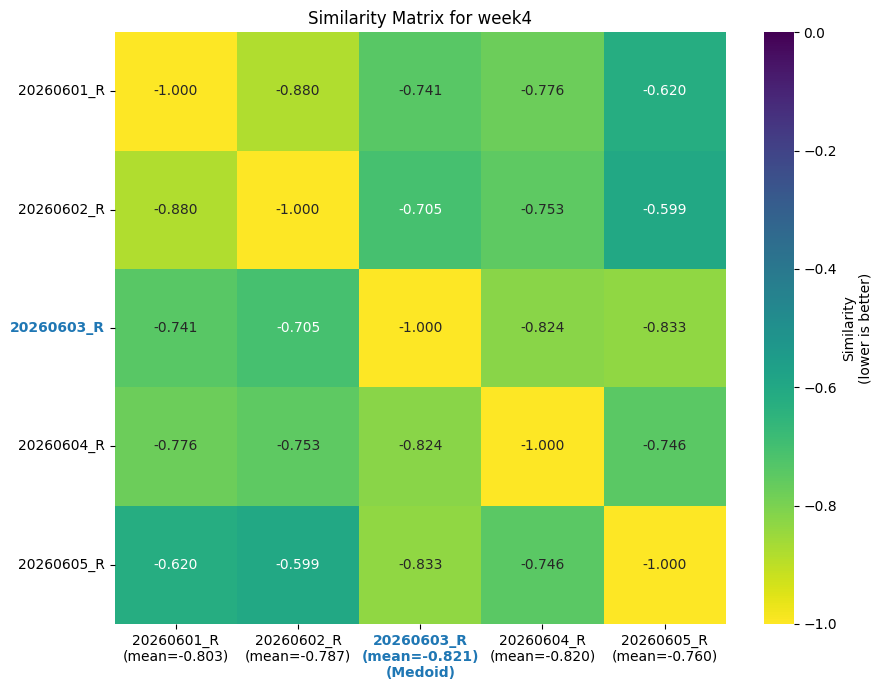

Weeks:  33%|███▎      | 3/9 [00:54<01:29, 14.88s/it]

Medoid image for week4: 20260603_R_crop_64.tif
NumPy shape: (41, 64, 64)
ANTs shape: (41, 64, 64)
ANTs spacing (ZYX, um): (5.0, 0.693359375, 0.693359375)
Approximate physical extent (um): (205.0, 44.375, 44.375)



Weeks:  33%|███▎      | 3/9 [00:59<01:29, 14.88s/it]          

Registered image saved: 20260601_R_crop_64_SyN.tif
Registered G channel image saved: 20260601_G_crop_64_SyN.tif



Weeks:  33%|███▎      | 3/9 [01:00<01:29, 14.88s/it]                  

...


Weeks:  33%|███▎      | 3/9 [01:02<01:29, 14.88s/it]                  

Registered image saved: 20260605_R_crop_64_SyN.tif
Registered G channel image saved: 20260605_G_crop_64_SyN.tif
Average image saved: week4_average.tif
2026-07-13 09:46:40,628 [io INFO] reading tiff with 41 planes


100%|██████████| 41/41 [00:00<00:00, 1973.11it/s]

2026-07-13 09:46:40,654 [core INFO] running YX: 41 planes of size (64, 64)
2026-07-13 09:46:40,655 [utils INFO] 
2026-07-13 09:46:40,655 [utils INFO] 0%|          | 0/6 [00:00<?, ?it/s]
2026-07-13 09:46:40,656 [utils INFO] 


2026-07-13 09:46:41,756 [utils INFO] 100%|##########| 6/6 [00:01<00:00,  5.46it/s]
2026-07-13 09:46:41,757 [core INFO] running ZY: 64 planes of size (41, 64)
2026-07-13 09:46:41,758 [utils INFO] 
2026-07-13 09:46:41,759 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:46:41,759 [utils INFO] 
2026-07-13 09:46:43,166 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.69it/s]
2026-07-13 09:46:43,167 [core INFO] running ZX: 64 planes of size (41, 64)
2026-07-13 09:46:43,167 [utils INFO] 
2026-07-13 09:46:43,168 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:46:43,168 [utils INFO] 
2026-07-13 09:46:44,570 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.71it/s]
2026-07-13 09:46:44,573 [models INFO] network run in 3.92s
2026-07-13 09:46:44,599 [models INFO] masks created in 0.03s


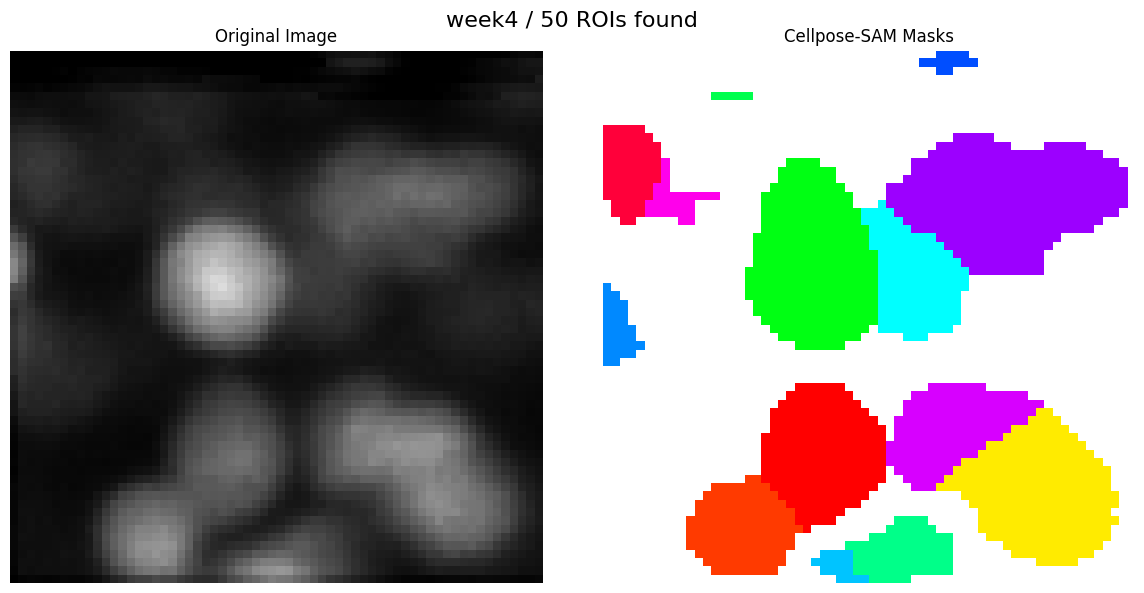

Weeks:  44%|████▍     | 4/9 [01:06<01:26, 17.31s/it]

Mask image saved: week4_average_cp_masks.tif
Processing week5 (1 red-channel images)


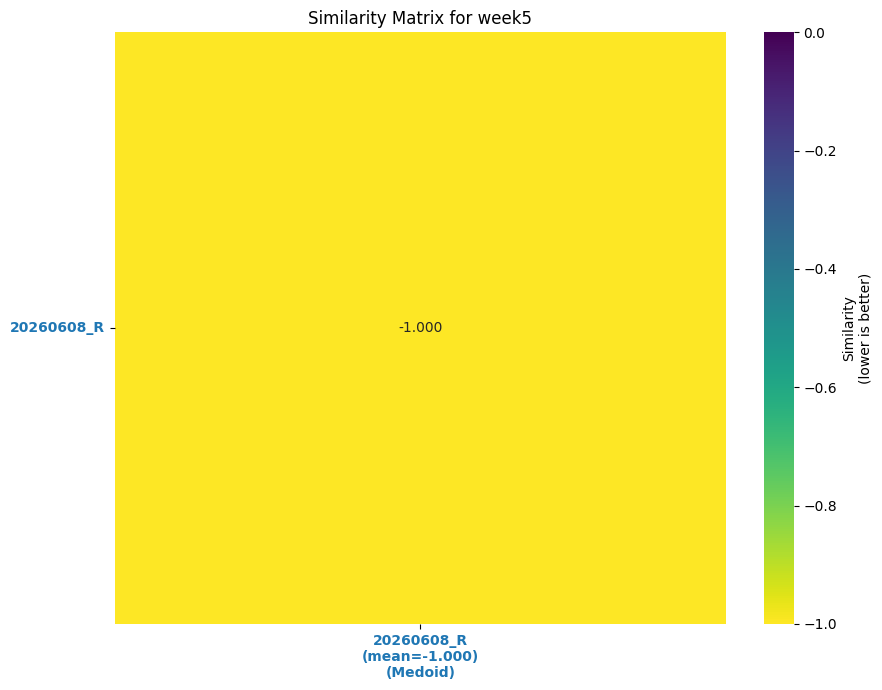

Weeks:  44%|████▍     | 4/9 [01:07<01:26, 17.31s/it]

Medoid image for week5: 20260608_R_crop_64.tif


Weeks:  44%|████▍     | 4/9 [01:07<01:26, 17.31s/it]

NumPy shape: (41, 64, 64)
ANTs shape: (41, 64, 64)
ANTs spacing (ZYX, um): (5.0, 0.693359375, 0.693359375)
Approximate physical extent (um): (205.0, 44.375, 44.375)



Weeks:  44%|████▍     | 4/9 [01:07<01:26, 17.31s/it]          

Medoid image copied to: 20260608_R_crop_64_SyN.tif
Medoid G channel image copied to: 20260608_G_crop_64_SyN.tif
Average image saved: week5_average.tif
2026-07-13 09:46:45,085 [io INFO] reading tiff with 41 planes


100%|██████████| 41/41 [00:00<00:00, 1930.19it/s]

2026-07-13 09:46:45,111 [core INFO] running YX: 41 planes of size (64, 64)
2026-07-13 09:46:45,112 [utils INFO] 
2026-07-13 09:46:45,112 [utils INFO] 0%|          | 0/6 [00:00<?, ?it/s]
2026-07-13 09:46:45,113 [utils INFO] 


2026-07-13 09:46:46,025 [utils INFO] 100%|##########| 6/6 [00:00<00:00,  6.58it/s]
2026-07-13 09:46:46,026 [core INFO] running ZY: 64 planes of size (41, 64)
2026-07-13 09:46:46,027 [utils INFO] 
2026-07-13 09:46:46,027 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:46:46,028 [utils INFO] 
2026-07-13 09:46:47,452 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.62it/s]
2026-07-13 09:46:47,453 [core INFO] running ZX: 64 planes of size (41, 64)
2026-07-13 09:46:47,454 [utils INFO] 
2026-07-13 09:46:47,454 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:46:47,454 [utils INFO] 
2026-07-13 09:46:48,866 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.67it/s]
2026-07-13 09:46:48,868 [models INFO] network run in 3.76s
2026-07-13 09:46:48,893 [models INFO] masks created in 0.02s


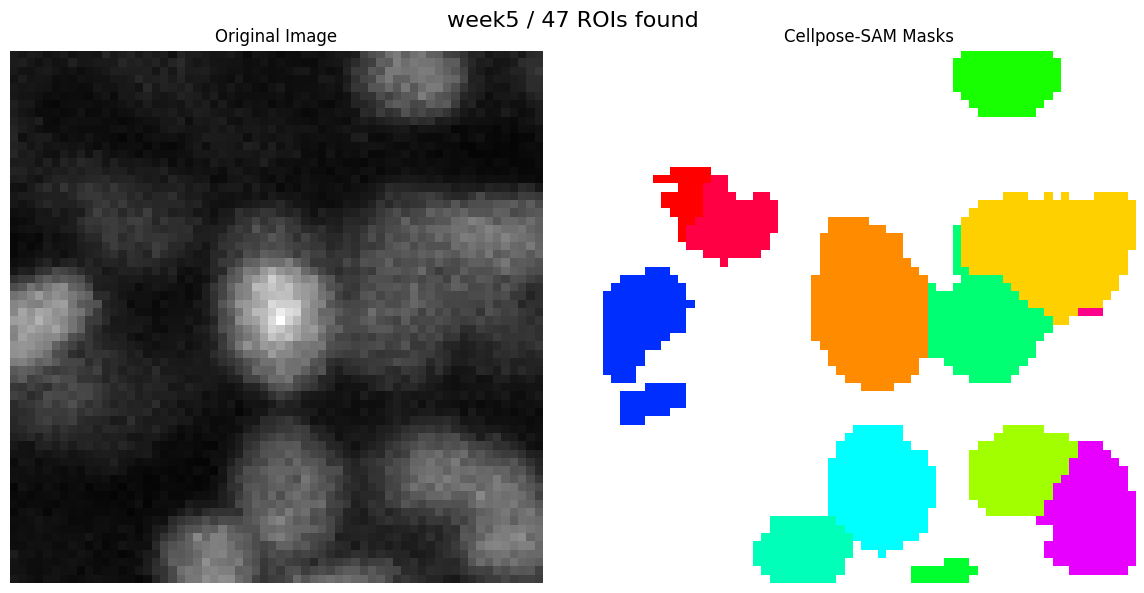

Weeks:  56%|█████▌    | 5/9 [01:11<00:50, 12.62s/it]

Mask image saved: week5_average_cp_masks.tif
Processing week6 (1 red-channel images)


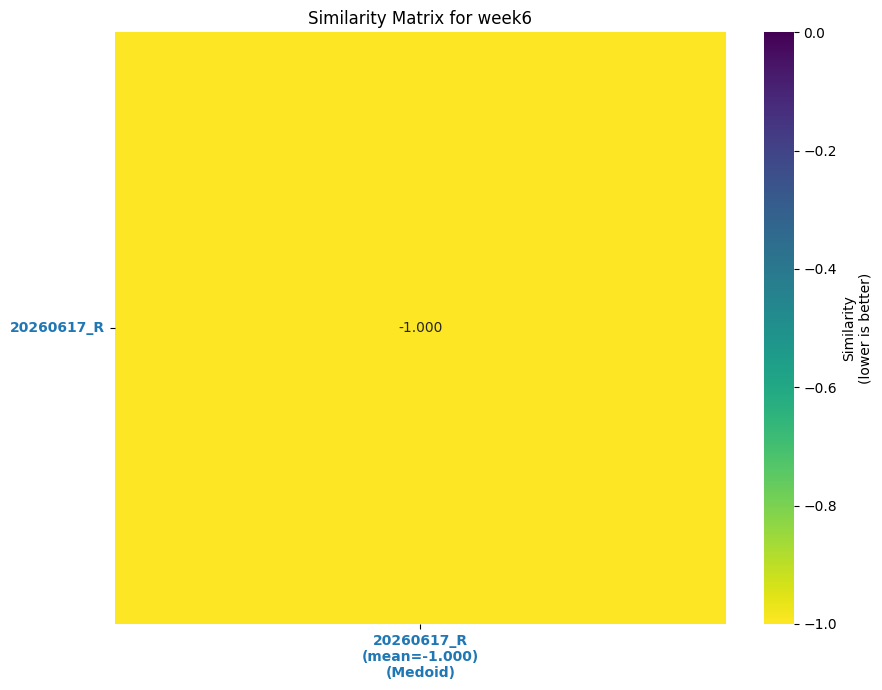

Weeks:  56%|█████▌    | 5/9 [01:11<00:50, 12.62s/it]

Medoid image for week6: 20260617_R_crop_64.tif


Weeks:  56%|█████▌    | 5/9 [01:11<00:50, 12.62s/it]

NumPy shape: (41, 64, 64)
ANTs shape: (41, 64, 64)
ANTs spacing (ZYX, um): (5.0, 0.693359375, 0.693359375)
Approximate physical extent (um): (205.0, 44.375, 44.375)



Weeks:  56%|█████▌    | 5/9 [01:11<00:50, 12.62s/it]          

Medoid image copied to: 20260617_R_crop_64_SyN.tif
Medoid G channel image copied to: 20260617_G_crop_64_SyN.tif
Average image saved: week6_average.tif
2026-07-13 09:46:49,382 [io INFO] reading tiff with 41 planes


100%|██████████| 41/41 [00:00<00:00, 1781.09it/s]

2026-07-13 09:46:49,410 [core INFO] running YX: 41 planes of size (64, 64)
2026-07-13 09:46:49,411 [utils INFO] 
2026-07-13 09:46:49,411 [utils INFO] 0%|          | 0/6 [00:00<?, ?it/s]
2026-07-13 09:46:49,412 [utils INFO] 


2026-07-13 09:46:50,325 [utils INFO] 100%|##########| 6/6 [00:00<00:00,  6.57it/s]
2026-07-13 09:46:50,326 [core INFO] running ZY: 64 planes of size (41, 64)
2026-07-13 09:46:50,327 [utils INFO] 
2026-07-13 09:46:50,327 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:46:50,328 [utils INFO] 
2026-07-13 09:46:51,748 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.64it/s]
2026-07-13 09:46:51,749 [core INFO] running ZX: 64 planes of size (41, 64)
2026-07-13 09:46:51,750 [utils INFO] 
2026-07-13 09:46:51,750 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:46:51,751 [utils INFO] 
2026-07-13 09:46:53,168 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.64it/s]
2026-07-13 09:46:53,171 [models INFO] network run in 3.76s
2026-07-13 09:46:53,198 [models INFO] masks created in 0.03s


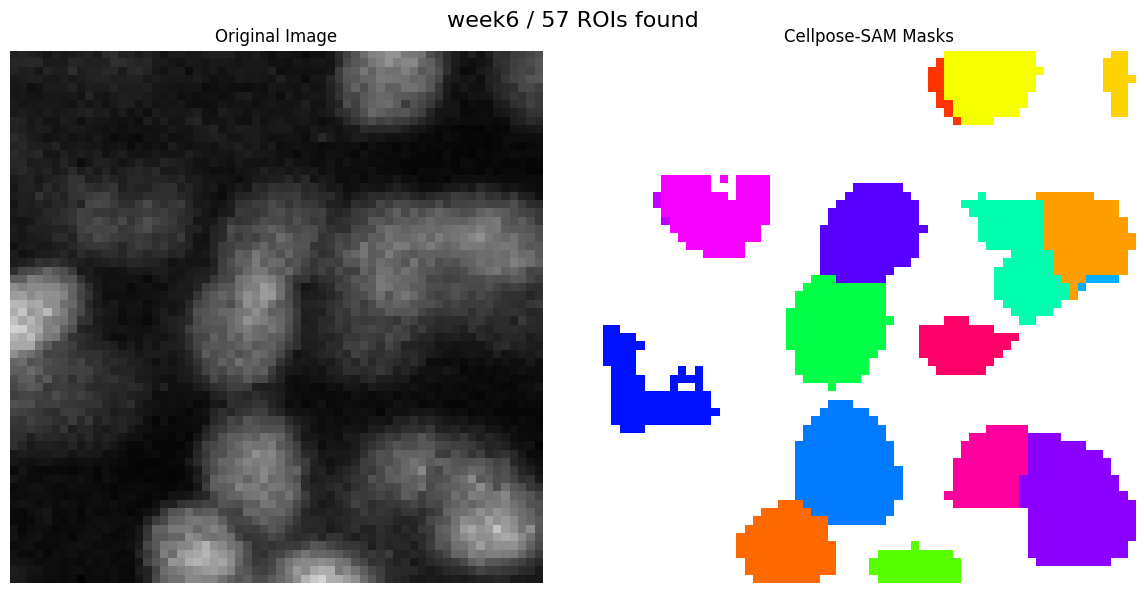

Weeks:  67%|██████▋   | 6/9 [01:15<00:29,  9.79s/it]

Mask image saved: week6_average_cp_masks.tif
Processing week7 (1 red-channel images)


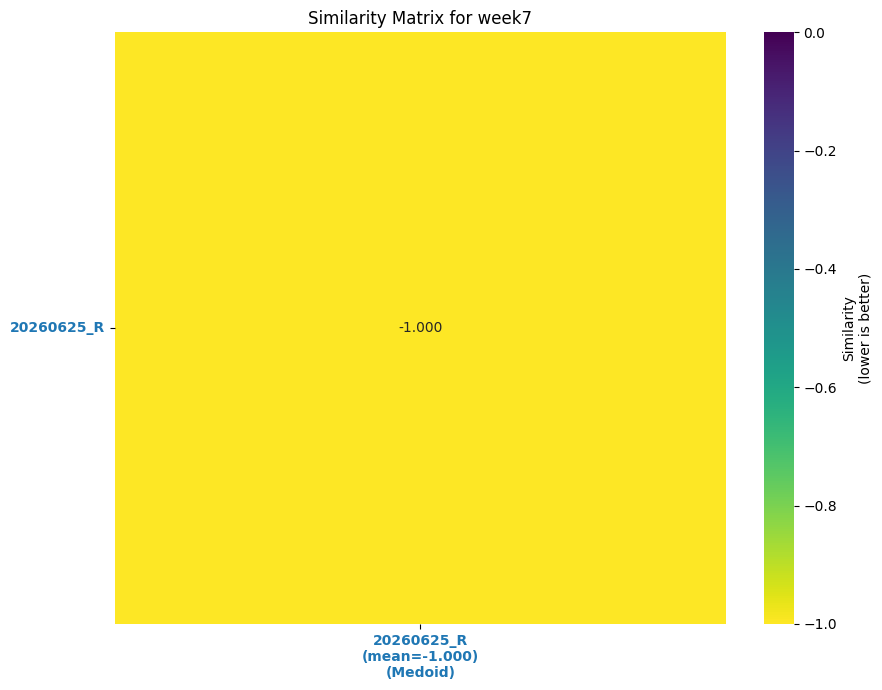

Weeks:  67%|██████▋   | 6/9 [01:15<00:29,  9.79s/it]

Medoid image for week7: 20260625_R_crop_64.tif


Weeks:  67%|██████▋   | 6/9 [01:15<00:29,  9.79s/it]

NumPy shape: (41, 64, 64)
ANTs shape: (41, 64, 64)
ANTs spacing (ZYX, um): (5.0, 0.693359375, 0.693359375)
Approximate physical extent (um): (205.0, 44.375, 44.375)



Weeks:  67%|██████▋   | 6/9 [01:15<00:29,  9.79s/it]          

Medoid image copied to: 20260625_R_crop_64_SyN.tif
Medoid G channel image copied to: 20260625_G_crop_64_SyN.tif
Average image saved: week7_average.tif
2026-07-13 09:46:53,694 [io INFO] reading tiff with 41 planes


100%|██████████| 41/41 [00:00<00:00, 1922.06it/s]

2026-07-13 09:46:53,720 [core INFO] running YX: 41 planes of size (64, 64)
2026-07-13 09:46:53,721 [utils INFO] 
2026-07-13 09:46:53,722 [utils INFO] 0%|          | 0/6 [00:00<?, ?it/s]
2026-07-13 09:46:53,723 [utils INFO] 


2026-07-13 09:46:54,641 [utils INFO] 100%|##########| 6/6 [00:00<00:00,  6.54it/s]
2026-07-13 09:46:54,642 [core INFO] running ZY: 64 planes of size (41, 64)
2026-07-13 09:46:54,642 [utils INFO] 
2026-07-13 09:46:54,643 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:46:54,644 [utils INFO] 
2026-07-13 09:46:56,058 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.66it/s]
2026-07-13 09:46:56,059 [core INFO] running ZX: 64 planes of size (41, 64)
2026-07-13 09:46:56,060 [utils INFO] 
2026-07-13 09:46:56,060 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:46:56,061 [utils INFO] 
2026-07-13 09:46:57,459 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.72it/s]
2026-07-13 09:46:57,462 [models INFO] network run in 3.74s
2026-07-13 09:46:57,488 [models INFO] masks created in 0.03s


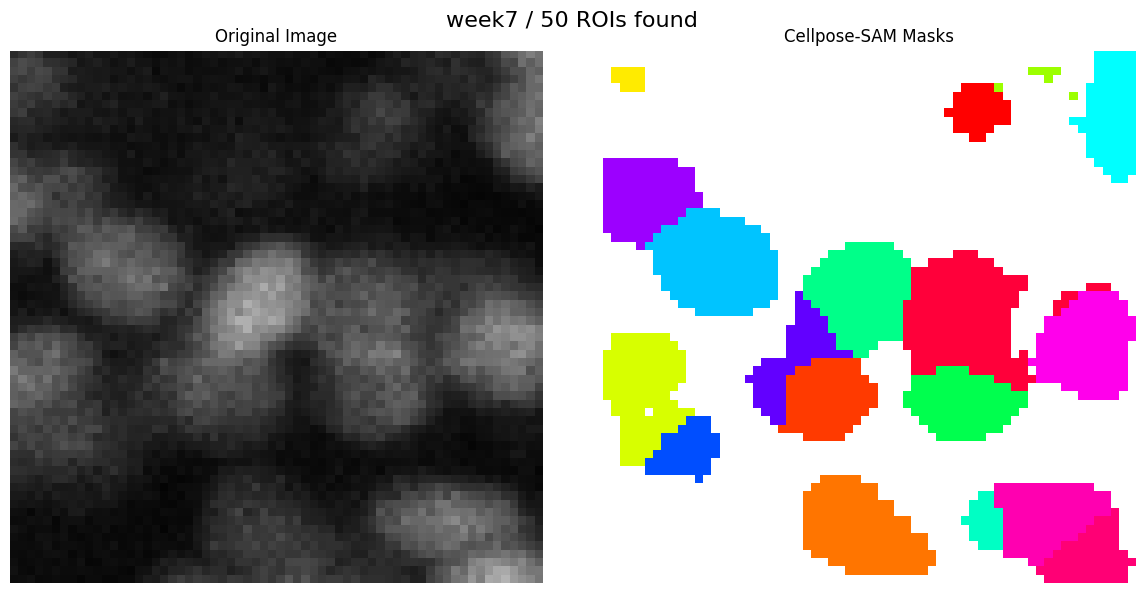

Weeks:  78%|███████▊  | 7/9 [01:19<00:15,  7.99s/it]

Mask image saved: week7_average_cp_masks.tif
Processing week8 (1 red-channel images)


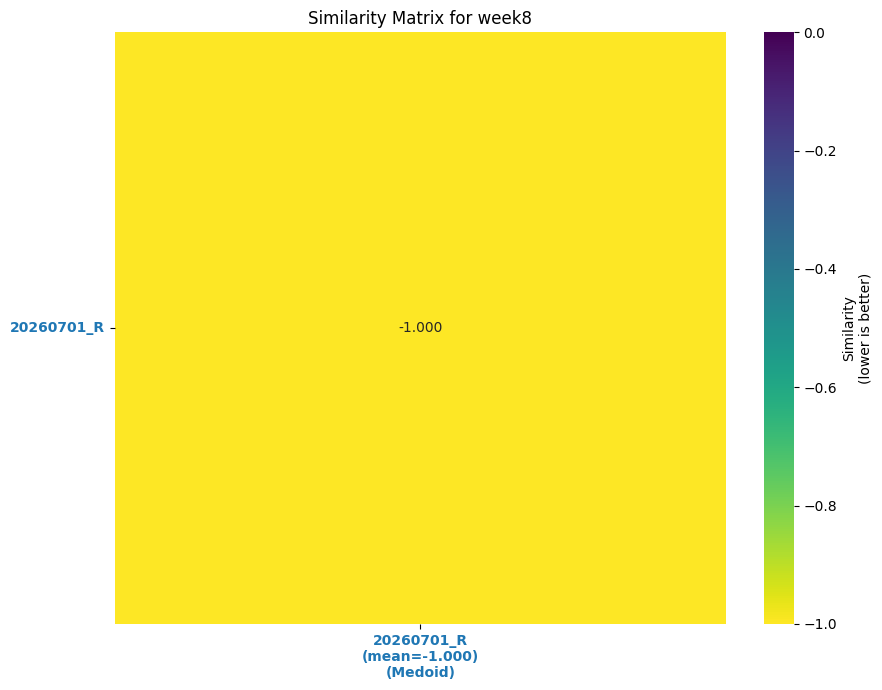

Weeks:  78%|███████▊  | 7/9 [01:20<00:15,  7.99s/it]

Medoid image for week8: 20260701_R_crop_64.tif
NumPy shape: (41, 64, 64)
ANTs shape: (41, 64, 64)
ANTs spacing (ZYX, um): (5.0, 0.693359375, 0.693359375)
Approximate physical extent (um): (205.0, 44.375, 44.375)



Weeks:  78%|███████▊  | 7/9 [01:20<00:15,  7.99s/it]          

Medoid image copied to: 20260701_R_crop_64_SyN.tif
Medoid G channel image copied to: 20260701_G_crop_64_SyN.tif
Average image saved: week8_average.tif
2026-07-13 09:46:57,995 [io INFO] reading tiff with 41 planes


100%|██████████| 41/41 [00:00<00:00, 1865.77it/s]

2026-07-13 09:46:58,022 [core INFO] running YX: 41 planes of size (64, 64)
2026-07-13 09:46:58,023 [utils INFO] 
2026-07-13 09:46:58,023 [utils INFO] 0%|          | 0/6 [00:00<?, ?it/s]
2026-07-13 09:46:58,023 [utils INFO] 


2026-07-13 09:46:58,957 [utils INFO] 100%|##########| 6/6 [00:00<00:00,  6.43it/s]
2026-07-13 09:46:58,959 [core INFO] running ZY: 64 planes of size (41, 64)
2026-07-13 09:46:58,960 [utils INFO] 
2026-07-13 09:46:58,960 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:46:58,961 [utils INFO] 
2026-07-13 09:47:00,381 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.63it/s]
2026-07-13 09:47:00,382 [core INFO] running ZX: 64 planes of size (41, 64)
2026-07-13 09:47:00,383 [utils INFO] 
2026-07-13 09:47:00,383 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:47:00,384 [utils INFO] 
2026-07-13 09:47:01,792 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.68it/s]
2026-07-13 09:47:01,795 [models INFO] network run in 3.77s
2026-07-13 09:47:01,821 [models INFO] masks created in 0.03s


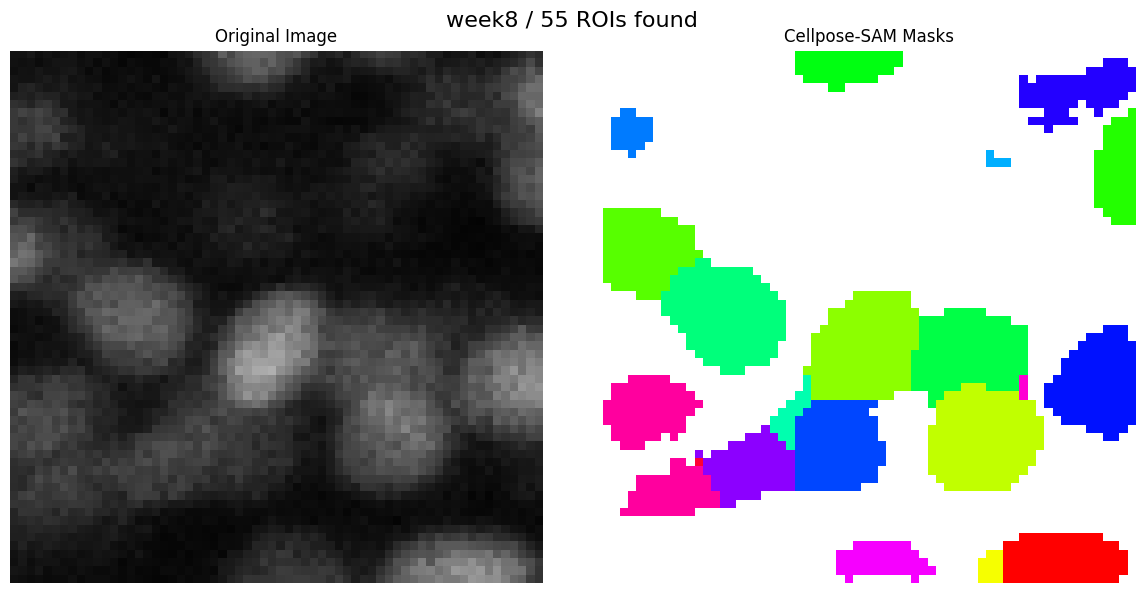

Weeks:  89%|████████▉ | 8/9 [01:24<00:06,  6.83s/it]

Mask image saved: week8_average_cp_masks.tif
Processing week9 (2 red-channel images)


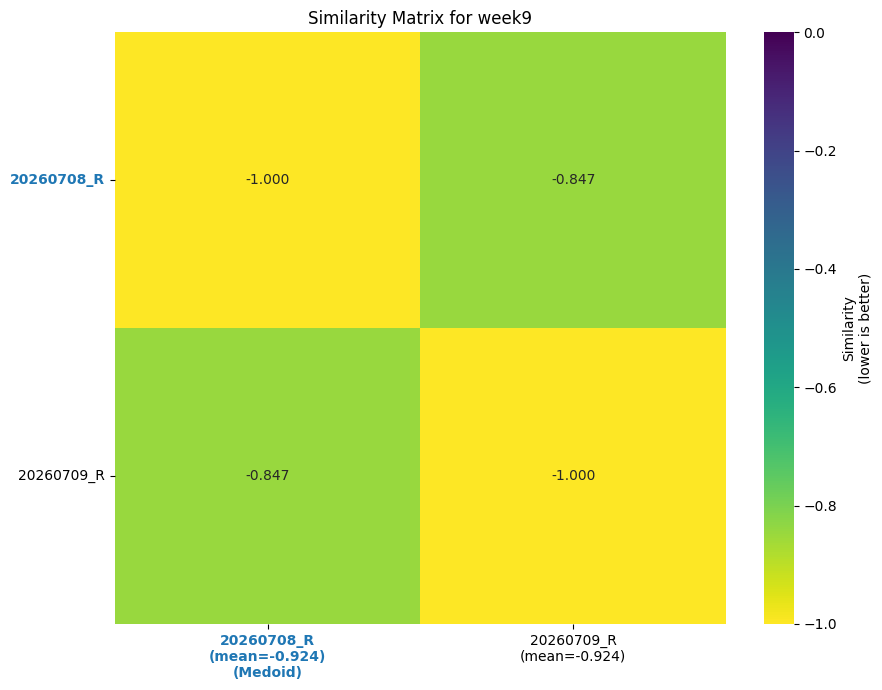

Weeks:  89%|████████▉ | 8/9 [01:25<00:06,  6.83s/it]

Medoid image for week9: 20260708_R_crop_64.tif
NumPy shape: (41, 64, 64)
ANTs shape: (41, 64, 64)
ANTs spacing (ZYX, um): (5.0, 0.693359375, 0.693359375)
Approximate physical extent (um): (205.0, 44.375, 44.375)



Weeks:  89%|████████▉ | 8/9 [01:25<00:06,  6.83s/it]          

Medoid image copied to: 20260708_R_crop_64_SyN.tif
Medoid G channel image copied to: 20260708_G_crop_64_SyN.tif



Weeks:  89%|████████▉ | 8/9 [01:26<00:06,  6.83s/it]          

Registered image saved: 20260709_R_crop_64_SyN.tif
Registered G channel image saved: 20260709_G_crop_64_SyN.tif
Average image saved: week9_average.tif
2026-07-13 09:47:03,920 [io INFO] reading tiff with 41 planes


100%|██████████| 41/41 [00:00<00:00, 1796.75it/s]

2026-07-13 09:47:03,948 [core INFO] running YX: 41 planes of size (64, 64)
2026-07-13 09:47:03,948 [utils INFO] 
2026-07-13 09:47:03,949 [utils INFO] 0%|          | 0/6 [00:00<?, ?it/s]
2026-07-13 09:47:03,949 [utils INFO] 


2026-07-13 09:47:05,063 [utils INFO] 100%|##########| 6/6 [00:01<00:00,  5.39it/s]
2026-07-13 09:47:05,064 [core INFO] running ZY: 64 planes of size (41, 64)
2026-07-13 09:47:05,065 [utils INFO] 
2026-07-13 09:47:05,065 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:47:05,066 [utils INFO] 
2026-07-13 09:47:06,485 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.64it/s]
2026-07-13 09:47:06,486 [core INFO] running ZX: 64 planes of size (41, 64)
2026-07-13 09:47:06,487 [utils INFO] 
2026-07-13 09:47:06,487 [utils INFO] 0%|          | 0/8 [00:00<?, ?it/s]
2026-07-13 09:47:06,487 [utils INFO] 
2026-07-13 09:47:07,894 [utils INFO] 100%|##########| 8/8 [00:01<00:00,  5.69it/s]
2026-07-13 09:47:07,897 [models INFO] network run in 3.95s
2026-07-13 09:47:07,924 [models INFO] masks created in 0.03s


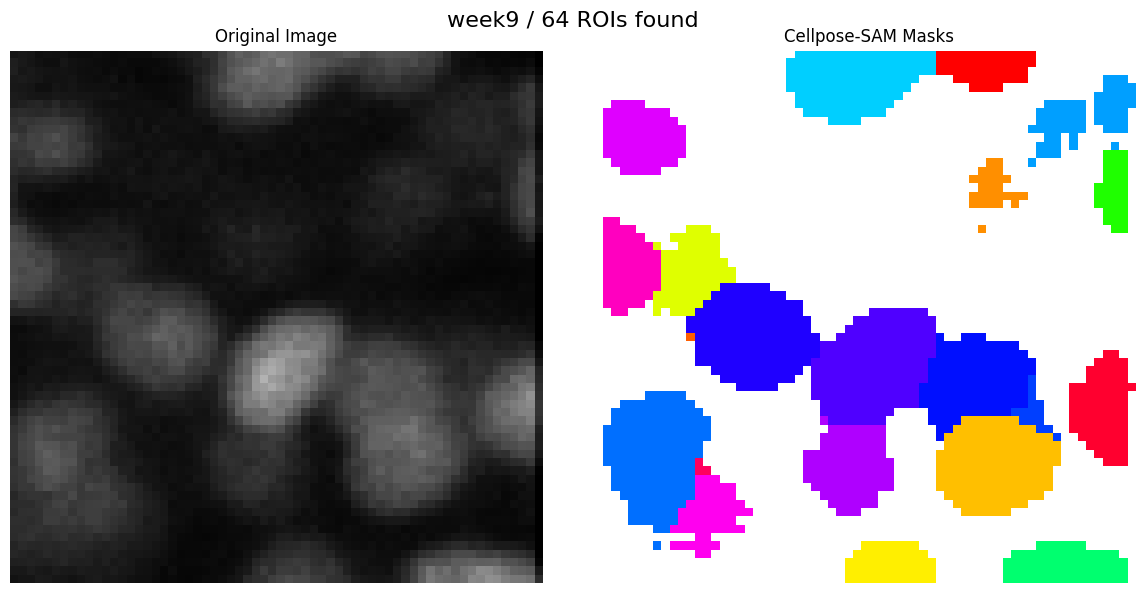

Weeks: 100%|██████████| 9/9 [01:30<00:00, 10.04s/it]

Mask image saved: week9_average_cp_masks.tif

Finished all weeks:
  week1: week1_average.tif, week1_average_cp_masks.tif
  week2: week2_average.tif, week2_average_cp_masks.tif
  week3: week3_average.tif, week3_average_cp_masks.tif
  week4: week4_average.tif, week4_average_cp_masks.tif
  week5: week5_average.tif, week5_average_cp_masks.tif
  week6: week6_average.tif, week6_average_cp_masks.tif
  week7: week7_average.tif, week7_average_cp_masks.tif
  week8: week8_average.tif, week8_average_cp_masks.tif
  week9: week9_average.tif, week9_average_cp_masks.tif


In [ ]:
## after grouping the files by week, automatically loop through every week in week_dict
## to find each weekly medoid, register images within the week, make the weekly average image,
## and run Cellpose-SAM on that average image.

import itertools
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from cellpose import io as cp_io
from cellpose import models, plot
from cellpose.io import imread_3D

cp_io.logger_setup()
model = models.CellposeModel(gpu=True, pretrained_model='cpsam_v2')


def calculate_similarity_dict(week_list, week_name):
    similarity_dict = {}
    total_pairs = len(week_list) * (len(week_list) + 1) // 2
    pair_iter = itertools.combinations_with_replacement(week_list, 2)

    for a, b in tqdm(pair_iter, total=total_pairs, desc=f'{week_name}: affine similarity', leave=False):
        a_numpy = io.imread(a)
        b_numpy = io.imread(b)
        a_ants = ants_from_zyx(a_numpy)
        b_ants = ants_from_zyx(b_numpy)

        ## apply quick affine registration first before assessing correlation
        if a == b:
            ## the similarity of the same image is fixed to -1, we can skip the computation
            similarity = -1.0
        else:
            warped_parms = ants.registration(fixed=a_ants, moving=b_ants, type_of_transform='Affine')
            warped_b_ants = warped_parms['warpedmovout']
            similarity = ants.image_similarity(a_ants, warped_b_ants, metric_type='Correlation', sampling_strategy="regular", sampling_percentage=0.25)
            ## only use 25% voxel for sampling so it's faster, the main results are the same anyway
        similarity_dict[(a, b)] = similarity

    return similarity_dict


def build_similarity_matrix(week_list, similarity_dict):
    similarity_matrix = np.zeros((len(week_list), len(week_list)))
    for i, a in enumerate(week_list):
        for j, b in enumerate(week_list):
            if i == j:
                similarity_matrix[i, j] = similarity_dict[(a, b)]
            elif (a, b) in similarity_dict:
                similarity_matrix[i, j] = similarity_dict[(a, b)]
            elif (b, a) in similarity_dict:
                similarity_matrix[i, j] = similarity_dict[(b, a)]
            else:
                similarity_matrix[i, j] = 0.0

    similarity_df = pd.DataFrame(
        similarity_matrix,
        index=[Path(f).name.split('_crop')[0] for f in week_list],
        columns=[Path(f).name.split('_crop')[0] for f in week_list],
    )
    return similarity_matrix, similarity_df


def get_medoid_index(similarity_matrix):
    similarity_sums = np.nansum(similarity_matrix, axis=1)
    medoid_index = np.nanargmin(similarity_sums)
    return medoid_index, similarity_sums


def plot_similarity_heatmap(similarity_df, similarity_matrix, week_list, week_name, medoid_index):
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        similarity_df,
        annot=True,
        fmt='.3f',
        cmap='viridis_r',
        cbar_kws={'label': 'Similarity\n(lower is better)'},
        vmin=-1,
        vmax=0,
    )
    plt.title(f'Similarity Matrix for {week_name}')
    mean_similarity = np.nanmean(similarity_matrix, axis=1)
    plt.yticks(rotation=0)

    xtick_labels = [
        f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})"
        if i != medoid_index
        else f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})\n(Medoid)"
        for i, f in enumerate(week_list)
    ]
    plt.xticks(
        ticks=np.arange(len(week_list)) + 0.5,
        labels=xtick_labels,
        rotation=0,
        ha='center',
    )
    ax = plt.gca()
    for idx, label in enumerate(ax.get_xticklabels()):
        if idx == medoid_index:
            label.set_color('C0')
            label.set_fontweight('bold')
    for idx, label in enumerate(ax.get_yticklabels()):
        if idx == medoid_index:
            label.set_color('C0')
            label.set_fontweight('bold')
    plt.tight_layout()
    plt.show()
    plt.close()


weekly_registration_results = {}
week_names = sorted(week_dict, key=lambda name: int(name.replace('week', '')))

for week_name in tqdm(week_names, desc='Weeks'):
    week_n = int(week_name.replace('week', ''))
    week_list = [f for f in week_dict[week_name] if '_R' in f]

    if not week_list:
        tqdm.write(f'Skipping {week_name}: no red-channel files found.')
        continue

    tqdm.write(f'Processing {week_name} ({len(week_list)} red-channel images)')
    crop_output_dir = Path(week_list[0]).parent

    similarity_dict = calculate_similarity_dict(week_list, week_name)
    similarity_matrix, similarity_df = build_similarity_matrix(week_list, similarity_dict)
    medoid_index, similarity_sums = get_medoid_index(similarity_matrix)
    plot_similarity_heatmap(similarity_df, similarity_matrix, week_list, week_name, medoid_index)

    ## find the most similar image to all other images, which is the medoid image of that week
    medoid_image = week_list[medoid_index]
    tqdm.write(f'Medoid image for {week_name}: {Path(medoid_image).name}')

    ## perform SyN registration for all images in that week to the medoid image
    medoid_numpy = io.imread(medoid_image)
    medoid_ants = ants_from_zyx(medoid_numpy)
    tqdm.write(f'NumPy shape: {medoid_numpy.shape}')
    tqdm.write(f'ANTs shape: {medoid_ants.shape}')
    tqdm.write(f'ANTs spacing (ZYX, um): {medoid_ants.spacing}')
    tqdm.write(
        'Approximate physical extent (um): '
        f"{tuple(float(n) * float(s) for n, s in zip(medoid_ants.shape, medoid_ants.spacing))}"
    )

    registered_images = []
    for image_path in tqdm(week_list, desc=f'{week_name}: SyN registration', leave=False):
        if image_path == medoid_image:
            ## directly copy the medoid image to the output folder with "_SyN" suffix
            registered_numpy = io.imread(image_path)
            output_syn_path = Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"
            io.imsave(output_syn_path, registered_numpy, check_contrast=False)
            tqdm.write(f'Medoid image copied to: {output_syn_path.name}')

            ## same for green channel
            image_path_g = image_path.replace('_R', '_G')
            output_syn_path_g = Path(image_path_g).parent / f"{Path(image_path_g).stem}_SyN.tif"
            io.imsave(output_syn_path_g, io.imread(image_path_g), check_contrast=False)
            tqdm.write(f'Medoid G channel image copied to: {output_syn_path_g.name}')
        else:
            moving_numpy = io.imread(image_path)
            moving_ants = ants_from_zyx(moving_numpy)
            assert tuple(medoid_ants.spacing) == SPACING_ZYX
            assert tuple(moving_ants.spacing) == SPACING_ZYX
            assert medoid_ants.shape == moving_ants.shape

            reg = ants.registration(fixed=medoid_ants, moving=moving_ants, type_of_transform='SyN')
            registered_ants = reg['warpedmovout']
            registered_numpy = registered_ants.numpy().astype(np.uint16)
            output_syn_path = Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"
            io.imsave(output_syn_path, registered_numpy, check_contrast=False)
            tqdm.write(f'Registered image saved: {output_syn_path.name}')

            ## do the same for the G channel using the same transform as the R channel
            image_path_g = image_path.replace('_R', '_G')
            moving_ants_g = ants_from_zyx(io.imread(image_path_g))
            registered_ants_g = ants.apply_transforms(
                fixed=medoid_ants,
                moving=moving_ants_g,
                transformlist=reg['fwdtransforms'],
            )
            registered_numpy_g = registered_ants_g.numpy().astype(np.uint16)
            output_syn_path_g = Path(image_path_g).parent / f"{Path(image_path_g).stem}_SyN.tif"
            io.imsave(output_syn_path_g, registered_numpy_g, check_contrast=False)
            tqdm.write(f'Registered G channel image saved: {output_syn_path_g.name}')

        registered_images.append(registered_numpy.astype(np.float32, copy=False))

    ## make an average image of all registered images in that week
    average_image = np.nanmean(registered_images, axis=0)
    output_path = crop_output_dir / f'{week_name}_average.tif'
    io.imsave(output_path, average_image.astype(np.uint16), check_contrast=False)
    tqdm.write(f'Average image saved: {output_path.name}')

    ## run Cellpose-SAM on the weekly average image
    loaded_images = imread_3D(output_path.as_posix())
    masks, flows, styles = model.eval(
        loaded_images,
        do_3D=True,
        z_axis=0,
        channel_axis=3,
        min_size=100,
    )

    ## quick visualization of the middle slice
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    middle_slice = loaded_images.shape[0] // 2

    ax[0].imshow(loaded_images[middle_slice], cmap='gray', vmin=500, vmax=5000)
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    mask_rgb = plot.mask_overlay(loaded_images[middle_slice], masks[middle_slice])
    ax[1].imshow(mask_rgb)
    ax[1].set_title('Cellpose-SAM Masks')
    ax[1].axis('off')

    fig.suptitle(f'{week_name} / {masks.max()} ROIs found', fontsize=16)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    ## save masks as a tiff file
    output_mask_path = crop_output_dir / f'{week_name}_average_cp_masks.tif'
    tifffile.imwrite(output_mask_path, masks.astype(np.uint16), compression='zlib')
    tqdm.write(f'Mask image saved: {output_mask_path.name}')

    weekly_registration_results[week_name] = {
        'week_n': week_n,
        'week_list': week_list,
        'similarity_dict': similarity_dict,
        'similarity_matrix': similarity_matrix,
        'similarity_df': similarity_df,
        'similarity_sums': similarity_sums,
        'medoid_index': medoid_index,
        'medoid_image': medoid_image,
        'average_image_path': output_path.as_posix(),
        'average_mask_path': output_mask_path.as_posix(),
    }

print('\nFinished all weeks:')
for week_name, result in weekly_registration_results.items():
    print(
        f"  {week_name}: {Path(result['average_image_path']).name}, "
        f"{Path(result['average_mask_path']).name}"
    )


In [ ]:
## similarity plotting is now handled inside Cell 6 for every week in week_dict
## rerun Cell 6 when you want to regenerate all weekly medoid plots


In [ ]:
## SyN registration is now handled inside Cell 6 for every week in week_dict
## this cell is intentionally left as a placeholder


In [ ]:
## Cellpose-SAM segmentation is now handled inside Cell 6 for every week in week_dict
## this cell is intentionally left as a placeholder


In [ ]:
## weekly registration + segmentation now runs automatically in Cell 6
## per-week outputs are stored in weekly_registration_results for later inspection
## downstream exploratory cells will still use the last processed week unless you reassign from that dict


Similarity between week1_average.tif and week1_average.tif: -1.0
Similarity between week1_average.tif and week2_average.tif: -0.6691077351570129
Similarity between week1_average.tif and week3_average.tif: -0.39546647667884827
Similarity between week1_average.tif and week4_average.tif: -0.23982751369476318
Similarity between week1_average.tif and week5_average.tif: -0.1705770343542099
Similarity between week1_average.tif and week6_average.tif: -0.00012926175259053707
Similarity between week1_average.tif and week7_average.tif: -0.05641717091202736
Similarity between week1_average.tif and week8_average.tif: -0.00044302071910351515
Similarity between week1_average.tif and week9_average.tif: -0.11559794098138809
Similarity between week2_average.tif and week2_average.tif: -1.0
Similarity between week2_average.tif and week3_average.tif: -0.5749030709266663
Similarity between week2_average.tif and week4_average.tif: -0.28028562664985657
Similarity between week2_average.tif and week5_average.ti

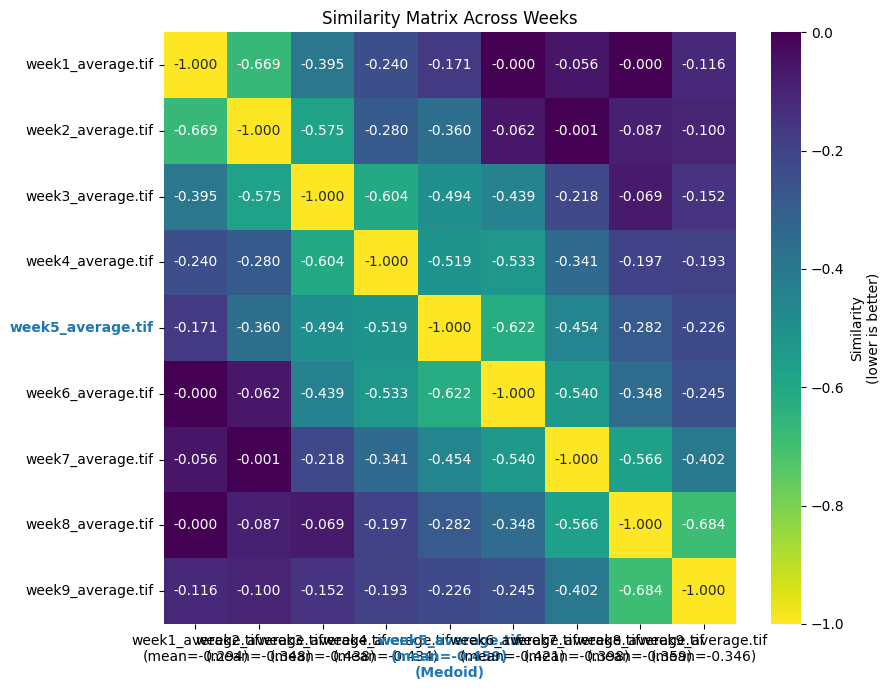

Medoid image for across weeks: week5_average.tif


In [6]:
## after the average images are done, let's compute the mediod image from the averaged images and then use it as the reference image to match the cell masks
average_file_list = sorted(glob(f"{folder_path}/crop_{crop_size}/*.tif"))
average_file_list = [f for f in average_file_list if 'average' in f]
average_file_list = [f for f in average_file_list if 'mask' not in f]
average_file_list = [f for f in average_file_list if 'SyN' not in f]

average_file_list

similarity_dict = {}
## loop through all pairs of images in the week and calculate their similarity, including self-similarity (which should be the highest/lowestes in MI)
for a, b in itertools.combinations_with_replacement(average_file_list, 2):
    # print(a.split('/')[-1], b.split('/')[-1])
    a_numpy = io.imread(a)
    b_numpy = io.imread(b)
    a_ants = ants_from_zyx(a_numpy)
    b_ants = ants_from_zyx(b_numpy)
    ## apply quick affine registration first before assessing correlation
    if a == b: # in case that we are comparing the same image, we don't need to register it to itself
        warped_b_ants = b_ants
        similarity = -1.0
    else:
        warped_parms = ants.registration(fixed=a_ants, moving=b_ants, type_of_transform='Affine')
        warped_b_ants = warped_parms['warpedmovout']

        # similarity = ants.image_similarity(a_ants, b_ants, metric_type='MattesMutualInformation')
        similarity = ants.image_similarity(a_ants, warped_b_ants, metric_type='Correlation') 

    print(f"Similarity between {a.split('/')[-1]} and {b.split('/')[-1]}: {similarity}")
    similarity_dict[(a, b)] = similarity

## plot simiarity matrix as a heatmap, with the file names as the x and y labels
import seaborn as sns
import pandas as pd
similarity_matrix = np.zeros((len(average_file_list), len(average_file_list)))
for i, a in enumerate(average_file_list):
    for j, b in enumerate(average_file_list):
        if i == j:
            similarity_matrix[i, j] = similarity_dict[(a, b)]
        elif (a, b) in similarity_dict:
            similarity_matrix[i, j] = similarity_dict[(a, b)]
        elif (b, a) in similarity_dict:
            similarity_matrix[i, j] = similarity_dict[(b, a)]
        else:
            similarity_matrix[i, j] = 0.0

similarity_df = pd.DataFrame(similarity_matrix, index=[Path(f).name for f in average_file_list], columns=[Path(f).name for f in average_file_list])

plt.figure(figsize=(9, 7))
sns.heatmap(similarity_df, annot=True, fmt=".3f", cmap='viridis_r', cbar_kws={'label': 'Similarity\n(lower is better)'},vmin=-1,vmax=0)
plt.title(f"Similarity Matrix Across Weeks")
mean_similarity = np.nanmean(similarity_matrix, axis=1)
# plt.xticks(ticks=np.arange(len(week_list))+0.5, labels=[f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})" for i, f in enumerate(week_list)], rotation=0, ha='center')
plt.yticks(rotation=0)
## highlight the medoid image (the one with the highest average similarity to all other images) by changing the color of its label
medoid_index = np.nanargmin(mean_similarity)
xtick_labels = [
    f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})"
    if i != medoid_index
    else f"{Path(f).name.split('_crop')[0]}\n(mean={mean_similarity[i]:.3f})\n(Medoid)"
    for i, f in enumerate(average_file_list)
]
plt.xticks(
    ticks=np.arange(len(average_file_list)) + 0.5,
    labels=xtick_labels,
    rotation=0,
    ha='center'
)
ax = plt.gca()
for idx, label in enumerate(ax.get_xticklabels()):
    if idx == medoid_index:
        label.set_color('C0')
        label.set_fontweight('bold')
for idx, label in enumerate(ax.get_yticklabels()):
    if idx == medoid_index:
        label.set_color('C0')
        label.set_fontweight('bold')
plt.tight_layout()
plt.show()


## find the most similar image to all other images, which is the medoid image of that week
similarity_sums = np.nansum(similarity_matrix, axis=1)
medoid_index = np.nanargmin(similarity_sums) # find the one with the smallest average distance to all other images
medoid_image = average_file_list[medoid_index]
print(f"Medoid image for across weeks: {Path(medoid_image).name}")



In [7]:
## then let's try do SyN registration from all averaged images to the mediod image, and then transform their cp_masks
## perform SyN registration for all images in that week to the medoid image, and save the registered images in the same folder with "_SyN" suffix
medoid_ants = ants_from_zyx(io.imread(medoid_image))
for image_path in average_file_list:
    if image_path == medoid_image:
        ## directly copy the medoid image to the output folder with "_SyN" suffix
        output_path = Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"
        io.imsave(output_path, io.imread(image_path), check_contrast=False)
        print(f"Medoid image copied to: {output_path.name}")
        ## same for green channel
        output_path_g = Path(image_path.replace('_R', '_G')).parent / f"{Path(image_path.replace('_R', '_G')).stem}_SyN.tif"
        io.imsave(output_path_g, io.imread(image_path.replace('_R', '_G')), check_contrast=False)
        print(f"Medoid G channel image copied to: {output_path_g.name}")
        ## same for the masks
        mask_path = image_path.replace("average","average_cp_masks")
        output_fname_mask = Path(mask_path).parent / f"{Path(mask_path).stem}_SyN.tif"
        io.imsave(output_fname_mask, io.imread(mask_path), compression='deflate', photometric="minisblack", check_contrast=False)
        print(f"Medoid mask image copied to: {output_fname_mask.name}")
        continue
    moving_ants = ants_from_zyx(io.imread(image_path))
    assert tuple(medoid_ants.spacing) == SPACING_ZYX
    assert tuple(moving_ants.spacing) == SPACING_ZYX
    assert medoid_ants.shape == moving_ants.shape
    reg = ants.registration(fixed=medoid_ants, moving=moving_ants, type_of_transform='SyN')
    registered_ants = reg['warpedmovout']
    registered_numpy = registered_ants.numpy()
    output_path = Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"
    io.imsave(output_path, registered_numpy.astype(np.uint16), check_contrast=False)
    print(f"Registered image saved: {output_path.name}")

    ## and do maks transformation too 
    ## note this is a forward transformation, not inverse
    mask_path = image_path.replace("average","average_cp_masks")
    ROI_mask_ants = ants_from_zyx(io.imread(mask_path), is_label=True)
    warped_ROI_mask = ants.apply_transforms(fixed=medoid_ants, moving=ROI_mask_ants, transformlist=reg['fwdtransforms'], interpolator='genericLabel')
    assert warped_ROI_mask.shape == registered_ants.shape
    assert tuple(warped_ROI_mask.spacing) == tuple(registered_ants.spacing)
    assert tuple(warped_ROI_mask.origin) == tuple(registered_ants.origin)
    assert np.array_equal(np.asarray(warped_ROI_mask.direction), np.asarray(registered_ants.direction))
    warped_ROI_mask_numpy = warped_ROI_mask.numpy().astype(np.uint16)
    output_fname_mask = Path(mask_path).parent / f"{Path(mask_path).stem}_SyN.tif"
    io.imsave(output_fname_mask, warped_ROI_mask_numpy, compression='deflate', photometric="minisblack", check_contrast=False)
    print(f"Output file saved: {output_fname_mask.name.split('/')[-1]}")


# ## make an average image of all registered images in that week, and save it as "weekX_average.tif"
# registered_images = []
# for image_path in average_file_list:
#     if image_path == medoid_image:
#         registered_images.append(io.imread(image_path))
#     else:
#         registered_images.append(io.imread(Path(image_path).parent / f"{Path(image_path).stem}_SyN.tif"))
# average_image = np.nanmean(registered_images, axis=0)
# output_path = Path(folder_path) /"crop_256" / f"grand_average.tif"
# io.imsave(output_path, average_image.astype(np.uint16), check_contrast=False)
# print(f"Average image saved: {output_path.name}")


Registered image saved: week1_average_SyN.tif
Output file saved: week1_average_cp_masks_SyN.tif


/tmp/ipykernel_925807/2963078957.py:42: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(output_fname_mask, warped_ROI_mask_numpy, compression='deflate', photometric="minisblack", check_contrast=False)


Registered image saved: week2_average_SyN.tif
Output file saved: week2_average_cp_masks_SyN.tif


/tmp/ipykernel_925807/2963078957.py:42: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(output_fname_mask, warped_ROI_mask_numpy, compression='deflate', photometric="minisblack", check_contrast=False)


Registered image saved: week3_average_SyN.tif
Output file saved: week3_average_cp_masks_SyN.tif


...

/tmp/ipykernel_925807/2963078957.py:42: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(output_fname_mask, warped_ROI_mask_numpy, compression='deflate', photometric="minisblack", check_contrast=False)


Registered image saved: week8_average_SyN.tif
Output file saved: week8_average_cp_masks_SyN.tif


/tmp/ipykernel_925807/2963078957.py:42: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(output_fname_mask, warped_ROI_mask_numpy, compression='deflate', photometric="minisblack", check_contrast=False)


Registered image saved: week9_average_SyN.tif
Output file saved: week9_average_cp_masks_SyN.tif


/tmp/ipykernel_925807/2963078957.py:42: FutureWarning: The plugin infrastructure in `skimage.io` is deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not pass additional keyword arguments for plugins (`**plugin_args`). Instead, use `imageio` or other I/O packages directly. See also `skimage.io.imsave`.
  io.imsave(output_fname_mask, warped_ROI_mask_numpy, compression='deflate', photometric="minisblack", check_contrast=False)


In [ ]:
## can stop here for now